<a href="https://colab.research.google.com/github/krobin2005/myportfolio/blob/main/dcs340/bottom_of_the_bowl_2d_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

going to use a toy function: this is a paraboloid i.e. bowl parabola

f(x,y) = (x-2)^2-xy+(y-3)^2

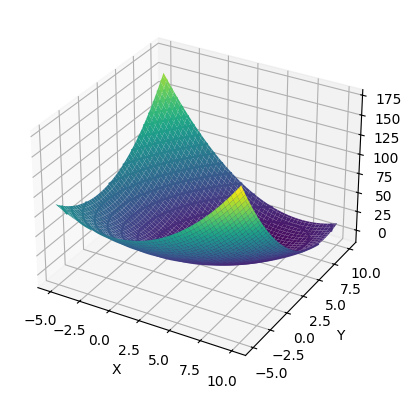

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

#define the height function of the terrain
def f(coordinates):
  x, y = coordinates
  return (x-2)**2 - x*y + (y-3)**2

#vizualization
x_range = np.linspace(-5, 10, 100)
y_range = np.linspace(-5, 10, 100)
X, Y = np.meshgrid(x_range, y_range) #all of the possible points in the 3D bowl
Z = f([X, Y])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.show()

#will tell you that this is a max or a min (in this case it is a min)
  #however you cannot tell where the max or min may be.

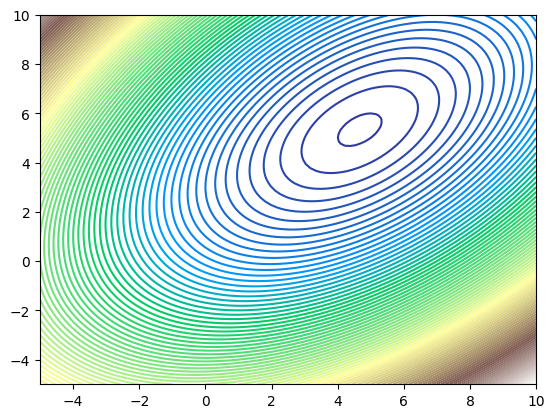

In [ ]:
plt.figure()
plt.contour(X, Y, Z, levels=100, cmap='terrain')
plt.show()
#this is the type of graphing you would use to represent hieght of a mountain "bulls-eye" == the max or min, depending on the scale

Nelder Mead Method:

In [ ]:
x0 = np.array([0.0,0.0])

res = minimize(f, x0, method='nelder-mead', options={'xatol': 1e-8, 'disp': True})
print(res)

Optimization terminated successfully.
         Current function value: -12.333333
         Iterations: 104
         Function evaluations: 206
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -12.333333333333336
             x: [ 4.667e+00  5.333e+00]
           nit: 104
          nfev: 206
 final_simplex: (array([[ 4.667e+00,  5.333e+00],
                       [ 4.667e+00,  5.333e+00],
                       [ 4.667e+00,  5.333e+00]]), array([-1.233e+01, -1.233e+01, -1.233e+01]))


Newton's Method:

Using the Rate of Change -- f()'

Using the Rate of the Rate of Change -- f()''

In [ ]:
def grad(xy):
  x, y = xy[0], xy[1]
  return np.array([2*(x-2) - y, -x + 2*(y-3)])

def hessian(xy):
  return np.array([[2.0, -1.0], [-1.0, 2.0]])

# Newton's Method Iteration Step
xy = np.array([0.0, 0.0])
print(f"Initial xy for Newton's Method: {xy}")

max_iterations_nm = 100 # Maximum iterations for Newton's Method
convergence_threshold_nm = 1e-8 # Convergence threshold

current_iteration = 0
for i in range(max_iterations_nm):
  g = grad(xy)
  H = hessian(xy)

  # Calculate the step using the inverse of the Hessian
  delta_xy = np.linalg.solve(H, g)

  # Check for convergence before updating
  if np.linalg.norm(delta_xy) < convergence_threshold_nm:
    print(f"Converged after {current_iteration} iterations. Final coordinates: {xy}")
    break

  xy = xy - delta_xy
  current_iteration += 1

  # Optional: print progress at each step, especially if not converging quickly
  # print(f"Iteration {current_iteration} xy: {xy}")

else:
    print(f"Maximum iterations ({max_iterations_nm}) reached without convergence. Final coordinates: {xy}")

print(f"\nFinal xy after Newton's Method: {xy}")
print(f"Function value f(xy) at final xy: {f(xy)}")

Initial xy for Newton's Method: [0. 0.]
Converged after 1 iterations. Final coordinates: [4.66666667 5.33333333]

Final xy after Newton's Method: [4.66666667 5.33333333]
Function value f(xy) at final xy: -12.333333333333336


### Recursive Gradient Descent to Find the Minimum

To find the minimum of the function `f(x, y)` recursively, we can implement a simple gradient descent algorithm. This involves calculating the partial derivatives (gradient) of the function with respect to `x` and `y`, and then iteratively updating the `x` and `y` values by moving a small step in the opposite direction of the gradient until convergence.

In [ ]:
# Define the partial derivatives (gradient) of f(x, y)
# f(x, y) = (x-2)**2 - x*y + (y-3)**2
# df/dx = 2*(x-2) - y = 2x - 4 - y
# df/dy = -x + 2*(y-3) = -x + 2y - 6

def gradient(x, y):
    df_dx = 2*x - 4 - y
    df_dy = -x + 2*y - 6
    return np.array([df_dx, df_dy])

def iterative_gradient_descent(coords, learning_rate, threshold, max_iterations):
    x, y = coords[0], coords[1]
    iteration = 0

    while iteration < max_iterations:
        grad = gradient(x, y)

        new_x = x - learning_rate * grad[0]
        new_y = y - learning_rate * grad[1]

        new_coords = np.array([new_x, new_y])

        change = np.linalg.norm(new_coords - np.array([x, y]))

        if change < threshold:
            print(f"Converged after {iteration} iterations. Final coordinates: ({new_x:.4f}, {new_y:.4f})")
            return new_coords

        x, y = new_x, new_y
        iteration += 1

    print(f"Maximum iterations reached. Current coordinates: ({x:.4f}, {y:.4f})")
    return np.array([x, y])


# Set initial parameters
initial_guess_iterative = np.array([0.0, 0.0]) # Start at (0,0)
learning_rate = 0.01
convergence_threshold = 1e-6
max_iterations = 100000 # Increased max_iterations for iterative version if needed

# Run the iterative gradient descent
print("Starting Iterative Gradient Descent...")
optimal_coords_iterative = iterative_gradient_descent(initial_guess_iterative, learning_rate, convergence_threshold, max_iterations)

# Calculate the minimum Z value using the found coordinates
min_Z_iterative = f(optimal_coords_iterative)

print(f"\nOptimal coordinates (x, y) found iteratively: {optimal_coords_iterative}")
print(f"Minimum value of Z found iteratively: {min_Z_iterative}")

Starting Iterative Gradient Descent...
Converged after 1112 iterations. Final coordinates: (4.6666, 5.3333)

Optimal coordinates (x, y) found iteratively: [4.66659733 5.333264  ]
Minimum value of Z found iteratively: -12.333333328526233


### Another Iterative Gradient Descent Implementation

This section provides another implementation of the iterative gradient descent algorithm to find the minimum of `f(x, y)`. It re-uses the `f` and `gradient` functions defined earlier to keep the code concise.

In [ ]:
# We'll assume 'f' and 'gradient' functions are already defined from previous cells.
# If you were running this cell independently, you might need to redefine them here:
# import numpy as np
# def f(coordinates):
#   x, y = coordinates
#   return (x-2)**2 - x*y + (y-3)**2
# def gradient(x, y):
#     df_dx = 2*x - 4 - y
#     df_dy = -x + 2*y - 6
#     return np.array([df_dx, df_dy])

def my_gradient_descent(initial_coords, learning_rate, threshold, max_iterations):
    x, y = initial_coords[0], initial_coords[1]
    iteration = 0

    print(f"Starting my_gradient_descent from initial point: ({x:.4f}, {y:.4f})")

    while iteration < max_iterations:
        grad = gradient(x, y)

        # Update coordinates
        new_x = x - learning_rate * grad[0]
        new_y = y - learning_rate * grad[1]

        new_coords = np.array([new_x, new_y])

        # Check for convergence
        change = np.linalg.norm(new_coords - np.array([x, y]))

        if change < threshold:
            print(f"Converged after {iteration} iterations. Final coordinates: ({new_x:.4f}, {new_y:.4f})")
            return new_coords

        x, y = new_x, new_y
        iteration += 1

        if iteration % 2000 == 0: # Print less frequently for this example
            print(f"Iteration {iteration}: Current coords = ({x:.4f}, {y:.4f}), Function value = {f([x, y]):.4f}")

    print(f"Maximum iterations reached ({max_iterations}). Current coordinates: ({x:.4f}, {y:.4f})")
    return np.array([x, y])


# --- Parameters for this Gradient Descent Run ---
initial_point = np.array([0.0, 0.0]) # Start at (0,0)
learning_rate_gd = 0.01
convergence_tol = 1e-6
max_iters = 100000

# Run the new gradient descent algorithm
optimal_coords_gd_new = my_gradient_descent(initial_point, learning_rate_gd, convergence_tol, max_iters)

# Calculate the minimum Z value at the found optimal coordinates
min_Z_gd_new = f(optimal_coords_gd_new)

print(f"\nMy Gradient Descent Results:")
print(f"Optimal coordinates (x, y): {optimal_coords_gd_new}")
print(f"Minimum function value (Z): {min_Z_gd_new}")

Starting my_gradient_descent from initial point: (0.0000, 0.0000)
Converged after 1112 iterations. Final coordinates: (4.6666, 5.3333)

My Gradient Descent Results:
Optimal coordinates (x, y): [4.66659733 5.333264  ]
Minimum function value (Z): -12.333333328526233
